# ITC6110 — NLP Group Project
## Notebook 2: Topic Modelling + Traditional ML Classification + XAI

**Steps covered:** 4.1 (Unsupervised — LDA), 4.2 Task 1 (Traditional ML Classifiers), XAI (LIME)

**Inputs:** artefacts saved by Notebook 1 (`data/processed/`)

---
## Colab Setup *(skip this cell if running locally)*

Run this cell first when opening in Google Colab. It clones the repo, installs
packages, and changes to the correct working directory.

In [ ]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO = '/content/itc6110-nlp-project'

    # Clone repo if not already present
    if not os.path.exists(REPO):
        os.system(f'git clone https://github.com/Geoanto8043/itc6110-nlp-project {REPO}')
        print("Repo cloned.")
    else:
        os.system(f'git -C {REPO} pull')
        print("Repo updated.")

    # Install packages (torch already available on Colab)
    os.system('pip install -q datasets gensim pyldavis wordcloud '
              'sentence-transformers faiss-cpu lime shap '
              'evaluate rouge_score accelerate transformers')
    print("Packages installed.")

    # Change to notebooks directory so relative paths (../data/) work
    os.chdir(f'{REPO}/notebooks')
    print(f"Working directory: {os.getcwd()}")

    # Optional: mount Google Drive to persist models between sessions
    # from google.colab import drive
    # drive.mount('/content/drive')
    # Then save models to /content/drive/MyDrive/nlp_project/models/
else:
    print("Running locally — Colab setup skipped.")
    print(f"Working directory: {os.getcwd()}")

---
## 0. Imports & Load Artefacts

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Gensim — LDA
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel

# pyLDAvis — interactive LDA plot
import pyLDAvis
import pyLDAvis.gensim_models

# sklearn — classifiers & evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.preprocessing import LabelEncoder

# XAI — LIME
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

SEED   = 42
FIGS   = Path('../outputs/figures')
MODELS = Path('../models')

np.random.seed(SEED)
print("Imports OK")

Imports OK


In [2]:
# Load processed dataset from Notebook 1
df = pd.read_csv('../data/processed/bbc_news_processed.csv')

# tokens column was saved as string — restore to list
import ast
df['tokens'] = df['tokens'].apply(ast.literal_eval)

print(f"Loaded {len(df)} articles, {df['category'].nunique()} categories")
print(df['category'].value_counts())

Loaded 2126 articles, 5 categories
category
sport            504
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64


In [ ]:
# Load TF-IDF artefacts from Notebook 1
with open('../data/processed/tfidf_matrix.pkl', 'rb') as f:
    tfidf_data = pickle.load(f)

X_tfidf  = tfidf_data['matrix']    # sparse (2126, 10000) — 2126 after NB1 dedup
tfidf_vec = tfidf_data['vectoriser']
y_labels  = tfidf_data['labels']   # category strings

# Encode labels as integers for sklearn
le = LabelEncoder()
y  = le.fit_transform(y_labels)

print(f"TF-IDF matrix: {X_tfidf.shape}")
print(f"Classes: {le.classes_}")

# Respect the original BBC train/test split
train_mask = df['split'] == 'train'
test_mask  = df['split'] == 'test'

# .values converts pandas Series → numpy array (required for scipy sparse indexing)
X_train, X_test = X_tfidf[train_mask.values], X_tfidf[test_mask.values]
y_train, y_test = y[train_mask.values], y[test_mask.values]

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

---
## 1. Unsupervised Learning — LDA Topic Modelling (Step 4.1)

LDA (Latent Dirichlet Allocation) discovers latent topics as probability
distributions over words, without using the category labels.
We first tune the number of topics K using the **C_v coherence score**,
then train the final model and visualise it with **pyLDAvis**.

In [4]:
# Build Gensim dictionary and corpus from pre-processed tokens
dictionary = corpora.Dictionary(df['tokens'])

# Filter extremes: remove tokens appearing in <5 or >80% of docs
dictionary.filter_extremes(no_below=5, no_above=0.80)

corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

print(f"Dictionary size after filtering: {len(dictionary):,} terms")
print(f"Corpus: {len(corpus)} documents")

Dictionary size after filtering: 7,692 terms
Corpus: 2126 documents


In [5]:
# Tune K: train LDA for K = 2..12 and compute C_v coherence
# C_v measures how often top words in a topic co-occur in the same documents.
# Higher coherence → more interpretable topics.

K_values    = range(2, 13)
coherence_scores = []

print("Tuning number of topics (K)...")
for k in K_values:
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=SEED,
        passes=10,
        alpha='auto',
        eta='auto',
    )
    cm = CoherenceModel(model=lda, texts=df['tokens'],
                        dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())
    print(f"  K={k:2d}  coherence={coherence_scores[-1]:.4f}")

best_k = K_values[np.argmax(coherence_scores)]
print(f"\nBest K = {best_k}  (coherence = {max(coherence_scores):.4f})")

Tuning number of topics (K)...
  K= 2  coherence=0.2932
  K= 3  coherence=0.3125
  K= 4  coherence=0.2790
  K= 5  coherence=0.3421
  K= 6  coherence=0.3560
  K= 7  coherence=0.3908
  K= 8  coherence=0.4407
  K= 9  coherence=0.4402
  K=10  coherence=0.4612
  K=11  coherence=0.3969
  K=12  coherence=0.4172

Best K = 10  (coherence = 0.4612)


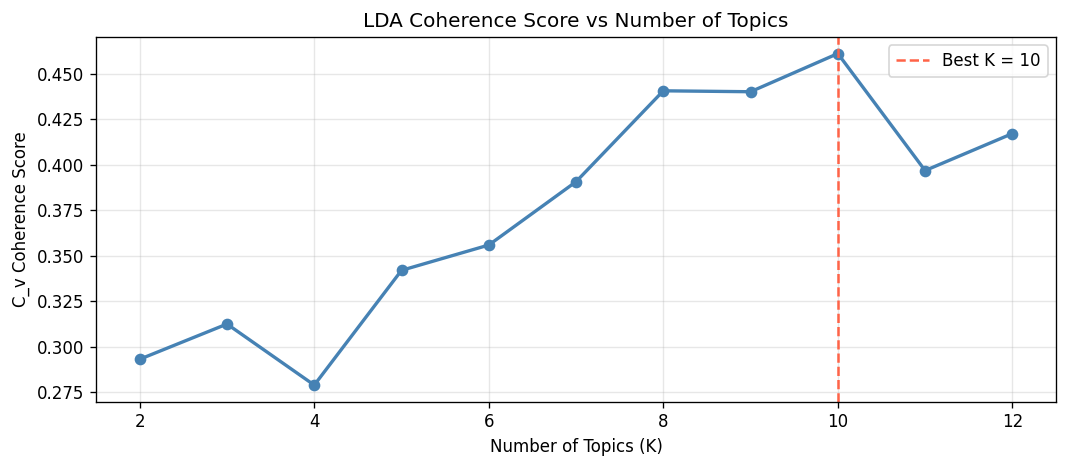

In [6]:
# Plot coherence vs number of topics
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_values, coherence_scores, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axvline(best_k, color='tomato', linestyle='--', label=f'Best K = {best_k}')
ax.set_xlabel('Number of Topics (K)')
ax.set_ylabel('C_v Coherence Score')
ax.set_title('LDA Coherence Score vs Number of Topics')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / '07_lda_coherence.png', bbox_inches='tight')
plt.show()

In [7]:
# Train final LDA model with best K
print(f"Training final LDA model with K={best_k}...")
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    random_state=SEED,
    passes=15,
    alpha='auto',
    eta='auto',
)
lda_model.save(str(MODELS / 'lda_model'))
print("Model saved to models/lda_model")

Training final LDA model with K=10...
Model saved to models/lda_model


In [8]:
# Topic keywords table — top 10 words per topic
print("=== LDA Topic Keywords ===\n")
rows = []
for topic_id in range(best_k):
    words = lda_model.show_topic(topic_id, topn=10)
    kws   = ', '.join([f"{w} ({p:.3f})" for w, p in words])
    top_words = [w for w, _ in words]
    rows.append({'Topic': f'Topic {topic_id + 1}', 'Top Keywords': kws})
    print(f"Topic {topic_id + 1}: {', '.join(top_words)}")

topic_df = pd.DataFrame(rows)
topic_df

=== LDA Topic Keywords ===

Topic 1: music, band, edward, top, back, new, year, sale, one, group
Topic 2: game, time, people, brown, life, online, would, world, hour, gaming
Topic 3: test, thanou, greek, blunkett, year, also, game, visa, kenteris, new
Topic 4: world, time, year, champion, holmes, olympic, speed, european, best, championship
Topic 5: technology, software, patent, company, network, machine, computer, one, people, new
Topic 6: mobile, phone, people, also, woman, game, digital, handset, get, technology
Topic 7: year, company, market, share, firm, would, price, month, sale, also
Topic 8: would, election, government, labour, party, minister, blair, police, say, tory
Topic 9: england, club, win, game, year, time, first, player, play, final
Topic 10: film, year, best, award, show, star, also, new, time, west


,Topic,Top Keywords
0,Topic 1,"music (0.011), band (0.010), edward (0.009), t..."
1,Topic 2,"game (0.022), time (0.009), people (0.009), br..."
2,Topic 3,"test (0.010), thanou (0.009), greek (0.009), b..."
3,Topic 4,"world (0.008), time (0.008), year (0.007), cha..."
4,Topic 5,"technology (0.009), software (0.009), patent (..."
5,Topic 6,"mobile (0.021), phone (0.019), people (0.013),..."
6,Topic 7,"year (0.011), company (0.008), market (0.007),..."
7,Topic 8,"would (0.012), election (0.009), government (0..."
8,Topic 9,"england (0.010), club (0.009), win (0.009), ga..."
9,Topic 10,"film (0.019), year (0.016), best (0.012), awar..."


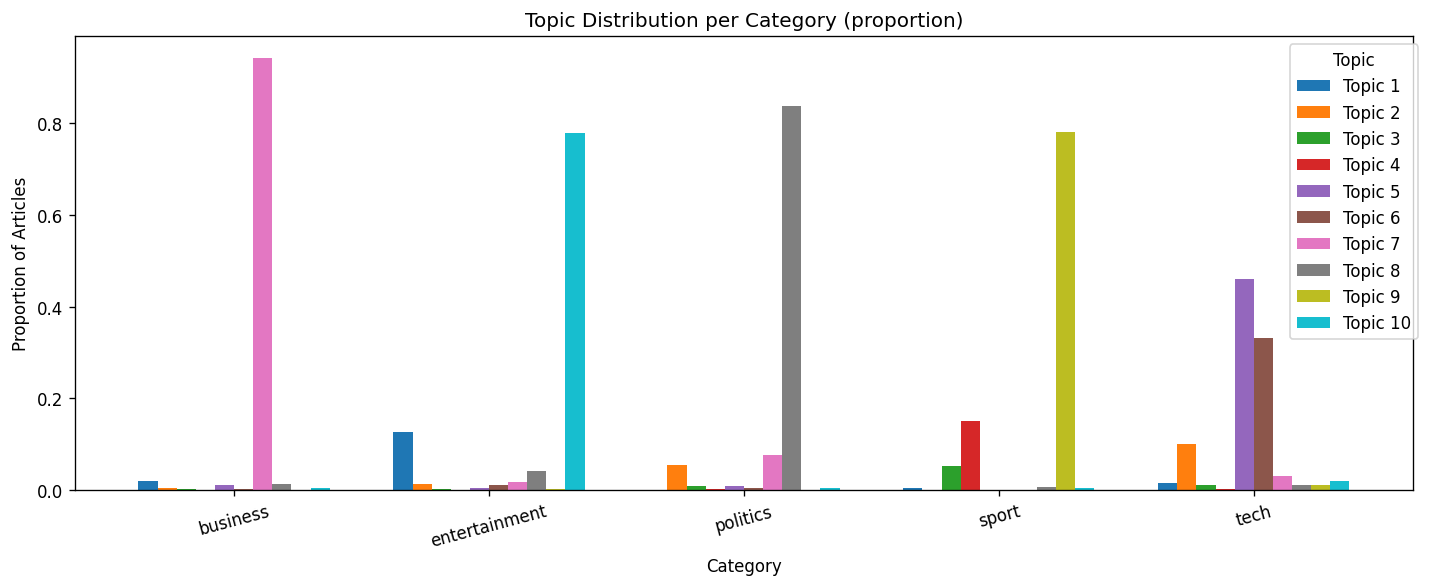

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
category,,,,,,,,,,
business,0.020,0.004,0.002,0.000,0.012,0.002,0.942,0.014,0.000,0.004
entertainment,0.127,0.014,0.003,0.000,0.005,0.011,0.019,0.041,0.003,0.778
politics,0.000,0.055,0.010,0.002,0.010,0.005,0.077,0.836,0.000,0.005
sport,0.006,0.000,0.052,0.151,0.000,0.000,0.000,0.008,0.780,0.004
tech,0.017,0.101,0.012,0.003,0.461,0.331,0.032,0.012,0.012,0.020


In [9]:
# Dominant topic per document
def get_dominant_topic(lda_model, corpus):
    dominant = []
    for bow in corpus:
        topic_probs = lda_model.get_document_topics(bow)
        dominant.append(max(topic_probs, key=lambda x: x[1])[0])
    return dominant

df['dominant_topic'] = get_dominant_topic(lda_model, corpus)

# Topic distribution across categories
topic_cat = pd.crosstab(df['category'], df['dominant_topic'],
                         normalize='index').round(3)
topic_cat.columns = [f'Topic {i+1}' for i in topic_cat.columns]

fig, ax = plt.subplots(figsize=(12, 5))
topic_cat.plot(kind='bar', ax=ax, colormap='tab10', width=0.75)
ax.set_title('Topic Distribution per Category (proportion)')
ax.set_xlabel('Category')
ax.set_ylabel('Proportion of Articles')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Topic', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(FIGS / '08_topic_per_category.png', bbox_inches='tight')
plt.show()
topic_cat

In [10]:
# pyLDAvis — interactive intertopic distance map
# Saved as HTML (open in browser) and displayed inline if running in Jupyter
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary,
                                      sort_topics=False)
pyLDAvis.save_html(vis, str(FIGS / 'lda_vis.html'))
print("Interactive LDA visualisation saved: outputs/figures/lda_vis.html")
pyLDAvis.enable_notebook()
vis  # renders inline in Jupyter

Interactive LDA visualisation saved: outputs/figures/lda_vis.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.072798  0.088893       1        1   5.292161
1      0.051452  0.067438       2        1   8.844694
2      0.012940 -0.257985       3        1   2.679341
3     -0.162186  0.002989       4        1   5.402987
4      0.174685  0.074565       5        1   9.269455
5      0.087366  0.138592       6        1   7.696871
6      0.110775 -0.042601       7        1  19.720640
7      0.096303 -0.099909       8        1  16.590835
8     -0.163200  0.006336       9        1  13.974568
9     -0.135337  0.021682      10        1  10.528448, topic_info=         Term         Freq        Total Category  logprob  loglift
1457     game  1807.000000  1807.000000  Default  30.0000  30.0000
451    mobile   678.000000   678.000000  Default  29.0000  29.0000
1565     film   917.000000   917.000000  Default  28.0000  28.0000
465     phone   696.000000   696.000000  Default  27.0000  27.0000
114   company  1117.000000  1117.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
874       one   198.614629  1698.886034  Topic10  -5.3750   0.1047
82      three   145.908504   765.214446  Topic10  -5.6834   0.5939
320      last   147.192695  1317.069757  Topic10  -5.6747   0.0597
229    people   129.469562  1796.570445  Topic10  -5.8030  -0.3791
175     would   130.083810  2458.731438  Topic10  -5.7982  -0.6881

[746 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
1545      1  0.044879      actor
1545     10  0.952426      actor
2710     10  0.992198    actress
6278      2  0.964057         ad
4784      1  0.987504  addiction
...     ...       ...        ...
2042      2  0.052833       york
2042      7  0.299390       york
2042     10  0.211334       york
4563      7  0.995940    yugansk
4564      7  0.998430      yukos

[1873 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [11]:
# (Extra) LDA on SPORT articles only — discover sub-topics within sport
sport_tokens = df[df['category'] == 'sport']['tokens'].tolist()
sport_dict   = corpora.Dictionary(sport_tokens)
sport_dict.filter_extremes(no_below=3, no_above=0.85)
sport_corpus = [sport_dict.doc2bow(t) for t in sport_tokens]

# Quick coherence scan for sport subset
sport_coh = []
K_sport   = range(2, 9)
for k in K_sport:
    m = LdaModel(sport_corpus, id2word=sport_dict, num_topics=k,
                 random_state=SEED, passes=15, alpha='auto', eta='auto')
    cm = CoherenceModel(model=m, texts=sport_tokens,
                        dictionary=sport_dict, coherence='c_v')
    sport_coh.append(cm.get_coherence())
    print(f"  Sport K={k}  coherence={sport_coh[-1]:.4f}")

best_k_sport = K_sport[np.argmax(sport_coh)]
print(f"\nBest K for sport subset = {best_k_sport}")

  Sport K=2  coherence=0.3800
  Sport K=3  coherence=0.4450
  Sport K=4  coherence=0.4784
  Sport K=5  coherence=0.4475
  Sport K=6  coherence=0.4372
  Sport K=7  coherence=0.4520
  Sport K=8  coherence=0.4263

Best K for sport subset = 4


In [ ]:
# train the sport-only LDA at the chosen K, then print each sub-topic's keywords
lda_sport = LdaModel(sport_corpus, id2word=sport_dict,
                     num_topics=best_k_sport, random_state=SEED,
                     passes=15, alpha='auto', eta='auto')

print("=== Sport Sub-Topics ===\n")
for i in range(best_k_sport):
    words = [w for w, _ in lda_sport.show_topic(i, topn=10)]
    print(f"Sport Topic {i+1}: {', '.join(words)}")

---
## 2. Supervised Learning — Traditional ML Classifiers (Step 4.2 Task 1)

We train **Logistic Regression**, **Naive Bayes**, and **Linear SVM** on
TF-IDF features, evaluate on the held-out test split, and compare results.

**Why re-fit TF-IDF per classifier?**
The TF-IDF saved by Notebook 1 was fit on the full dataset (to produce
document vectors for t-SNE). Here we use `Pipeline` to fit TF-IDF only on
the training split, preventing any data leakage into the test evaluation.

In [13]:
# Build pipelines — fit TF-IDF on train only to prevent leakage
X_train_raw = df[df['split'] == 'train']['text_processed'].values
X_test_raw  = df[df['split'] == 'test']['text_processed'].values

pipelines = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2)),
        ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=SEED,
                                     solver='lbfgs')),  # multi_class removed in sklearn 1.8
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2)),
        ('clf',   MultinomialNB(alpha=0.1)),
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2)),
        ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=SEED)),
    ]),
}

results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'macro_f1':  f1_score(y_test, y_pred, average='macro'),
        'y_pred':    y_pred,
        'report':    classification_report(y_test, y_pred,
                                           target_names=le.classes_),
    }
    print(f"── {name} ──")
    print(f"  Accuracy: {results[name]['accuracy']:.4f}  |  Macro F1: {results[name]['macro_f1']:.4f}")
    print()

── Logistic Regression ──
  Accuracy: 0.9678  |  Macro F1: 0.9669

── Naive Bayes ──
  Accuracy: 0.9646  |  Macro F1: 0.9628

── Linear SVM ──
  Accuracy: 0.9700  |  Macro F1: 0.9693



In [14]:
# Full classification reports
for name, res in results.items():
    print(f"{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(res['report'])

 Logistic Regression
               precision    recall  f1-score   support

     business       0.95      0.95      0.95       221
entertainment       0.99      0.96      0.98       163
     politics       0.95      0.96      0.96       167
        sport       0.98      1.00      0.99       230
         tech       0.96      0.95      0.96       151

     accuracy                           0.97       932
    macro avg       0.97      0.97      0.97       932
 weighted avg       0.97      0.97      0.97       932

 Naive Bayes
               precision    recall  f1-score   support

     business       0.96      0.94      0.95       221
entertainment       0.99      0.94      0.97       163
     politics       0.94      0.96      0.95       167
        sport       1.00      1.00      1.00       230
         tech       0.92      0.97      0.95       151

     accuracy                           0.96       932
    macro avg       0.96      0.96      0.96       932
 weighted avg       0.97  

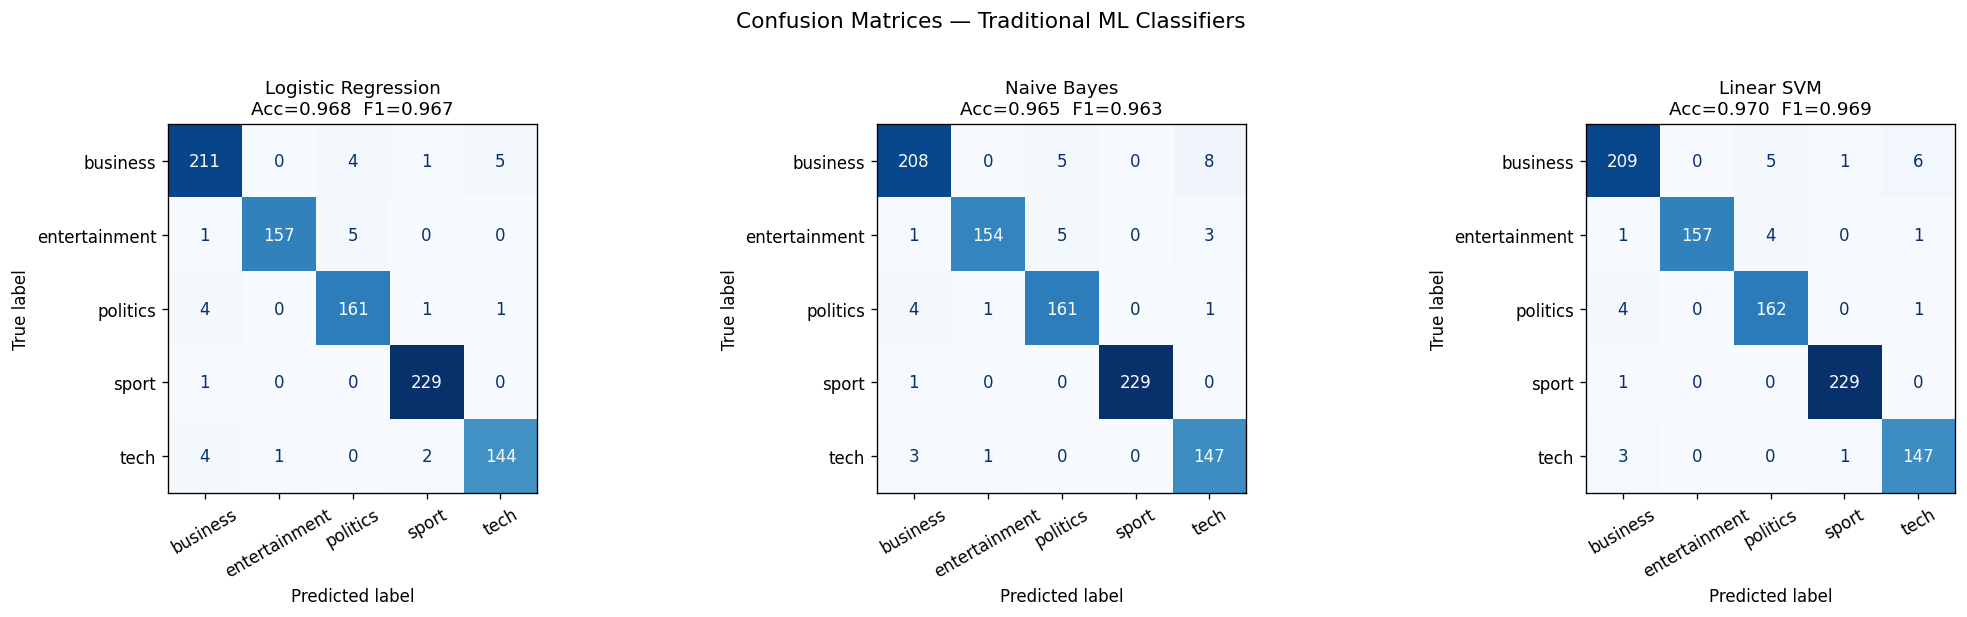

In [15]:
# Confusion matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f}  F1={res["macro_f1"]:.3f}',
                 fontsize=11)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Confusion Matrices — Traditional ML Classifiers', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '09_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [16]:
# Model comparison table
summary = pd.DataFrame({
    name: {'Accuracy': res['accuracy'], 'Macro F1': res['macro_f1']}
    for name, res in results.items()
}).T.round(4)
summary = summary.sort_values('Macro F1', ascending=False)
print("=== Model Comparison ===")
print(summary.to_string())
summary

=== Model Comparison ===
                     Accuracy  Macro F1
Linear SVM             0.9700    0.9693
Logistic Regression    0.9678    0.9669
Naive Bayes            0.9646    0.9628


,Accuracy,Macro F1
Linear SVM,0.9700,0.9693
Logistic Regression,0.9678,0.9669
Naive Bayes,0.9646,0.9628


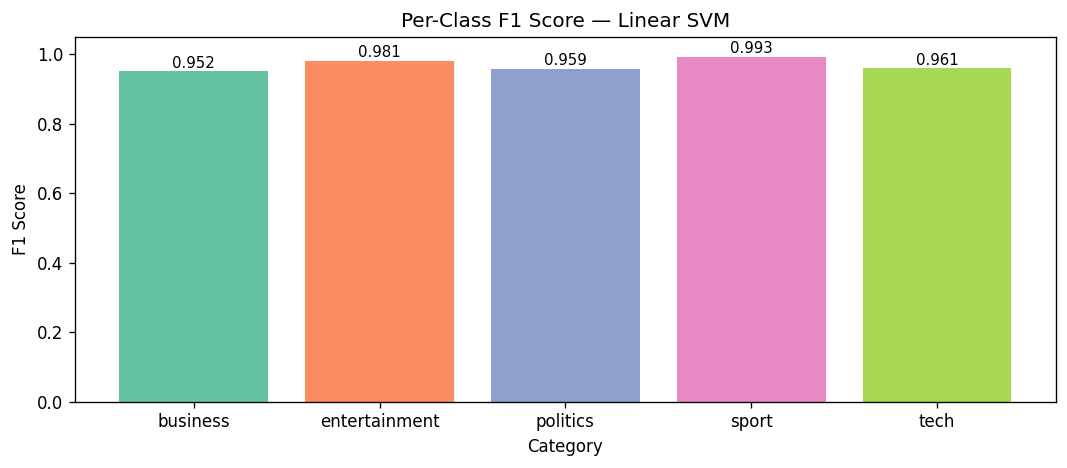

In [17]:
# Per-class F1 bar chart for best model
best_model_name = summary.index[0]
best_pipe       = pipelines[best_model_name]
y_pred_best     = results[best_model_name]['y_pred']

from sklearn.metrics import f1_score as f1_per_class
per_class_f1 = f1_score(y_test, y_pred_best, average=None)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(le.classes_, per_class_f1,
              color=sns.color_palette('Set2', len(le.classes_)))
ax.set_ylim(0, 1.05)
ax.set_title(f'Per-Class F1 Score — {best_model_name}')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Category')
for bar, v in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / '10_per_class_f1.png', bbox_inches='tight')
plt.show()

---
## 3. Explainable AI — LIME (Step 4.2 Task 1)

**LIME** (Local Interpretable Model-agnostic Explanations) explains individual
predictions by fitting a simple linear model in the neighbourhood of the
sample being explained.

We apply it to the **best classifier** and show:
1. A correctly classified sport article (local explanation)
2. A misclassified article (error analysis)

In [18]:
# LIME explainer — works on raw text via the best pipeline
explainer = LimeTextExplainer(class_names=le.classes_, random_state=SEED)

# Wrap pipeline predict_proba for LIME
# LinearSVC doesn't have predict_proba — use Logistic Regression for LIME
lime_pipe = pipelines['Logistic Regression']

def predict_proba_fn(texts):
    return lime_pipe.predict_proba(texts)

print(f"LIME will explain: Logistic Regression (has predict_proba)")
print(f"Classes: {le.classes_}")

LIME will explain: Logistic Regression (has predict_proba)
Classes: ['business' 'entertainment' 'politics' 'sport' 'tech']


In [19]:
# Pick a correctly classified SPORT article from the test set
test_df = df[df['split'] == 'test'].reset_index(drop=True)
y_pred_lr = pipelines['Logistic Regression'].predict(X_test_raw)
y_true_lr = y_test

# Sport articles correctly classified
sport_class = le.transform(['sport'])[0]
correct_sport_idx = np.where((y_pred_lr == sport_class) &
                              (y_true_lr == sport_class))[0]
idx = correct_sport_idx[0]

print(f"Explaining test article #{idx}")
print(f"True label:      {le.classes_[y_true_lr[idx]]}")
print(f"Predicted label: {le.classes_[y_pred_lr[idx]]}")
print(f"\nArticle snippet (first 400 chars):")
print(test_df['text_processed'].iloc[idx][:400])

Explaining test article #1
True label:      sport
Predicted label: sport

Article snippet (first 400 chars):
sydney host north south game sydney host northern versus southern hemisphere charity match june july australian rugby union aru said wednesday match include player lion tour new zealand australian rugby union thrown support behind proposed north south match raise fund tsunami appeal aru said date yet decided likely venue sydney olympic stadium aru chief executive gary flower said world cricket cha


Saved: outputs/figures/lime_explanation_sport.html


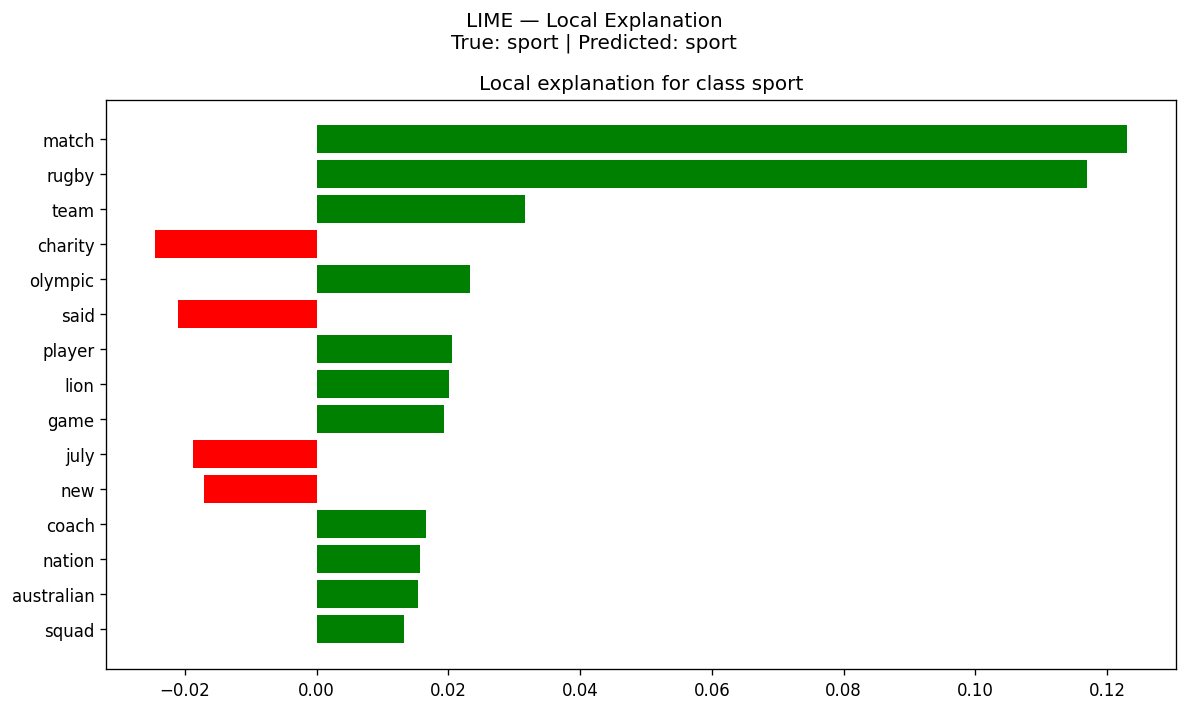

In [20]:
# Generate LIME explanation — local, single article
exp = explainer.explain_instance(
    test_df['text_processed'].iloc[idx],
    predict_proba_fn,
    num_features=15,
    num_samples=500,
    labels=[sport_class],
)

# Save as HTML and show inline
exp.save_to_file(str(FIGS / 'lime_explanation_sport.html'))
print("Saved: outputs/figures/lime_explanation_sport.html")

# Matplotlib version for the report
fig = exp.as_pyplot_figure(label=sport_class)
fig.suptitle(f'LIME — Local Explanation\nTrue: sport | Predicted: sport',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / '11_lime_sport_correct.png', bbox_inches='tight')
plt.show()

Total misclassified (LR): 30

Article #43
True:      tech
Predicted: business

Article snippet:
ownership double number personal computer worldwide expected double billion machine according report analyst forrester research growth driven emerging market china russia india report predicted third new pc market china adding million new pc said low priced computer made local company expected dominate territory forrester said report come less week ibm pioneer business sold hardware division china


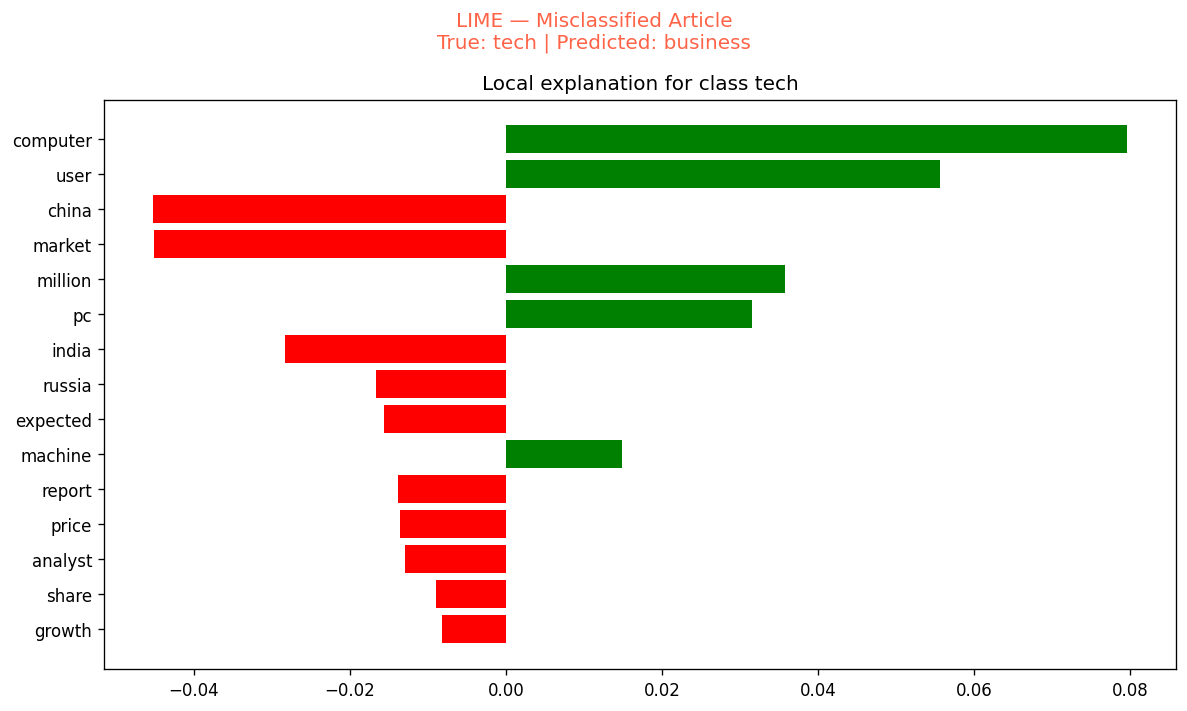

In [21]:
# Misclassified article — error analysis
wrong_idx_list = np.where(y_pred_lr != y_true_lr)[0]
print(f"Total misclassified (LR): {len(wrong_idx_list)}")

# Pick the first misclassified article
w_idx = wrong_idx_list[0]
true_lbl = le.classes_[y_true_lr[w_idx]]
pred_lbl = le.classes_[y_pred_lr[w_idx]]

print(f"\nArticle #{w_idx}")
print(f"True:      {true_lbl}")
print(f"Predicted: {pred_lbl}")
print(f"\nArticle snippet:")
print(test_df['text_processed'].iloc[w_idx][:400])

true_class_id = y_true_lr[w_idx]
exp_wrong = explainer.explain_instance(
    test_df['text_processed'].iloc[w_idx],
    predict_proba_fn,
    num_features=15,
    num_samples=500,
    labels=[true_class_id],
)

fig = exp_wrong.as_pyplot_figure(label=true_class_id)
fig.suptitle(f'LIME — Misclassified Article\nTrue: {true_lbl} | Predicted: {pred_lbl}',
             fontsize=12, color='tomato')
plt.tight_layout()
plt.savefig(FIGS / '12_lime_misclassified.png', bbox_inches='tight')
plt.show()

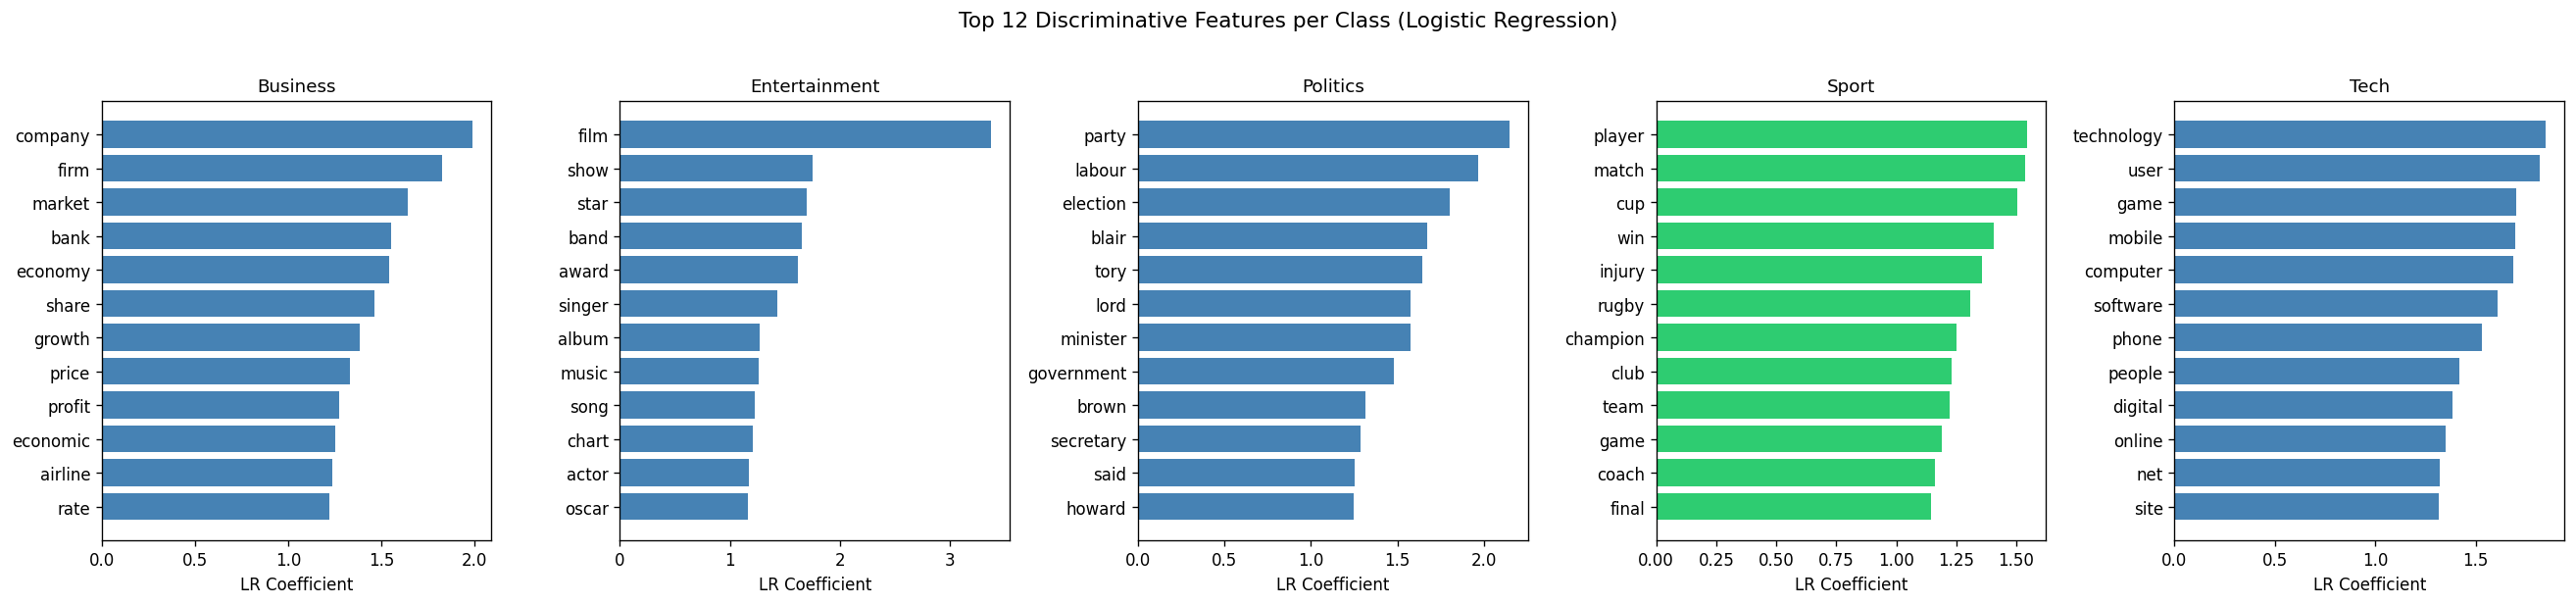

In [22]:
# Global feature importance — top TF-IDF features by LR coefficient per class
lr_clf    = pipelines['Logistic Regression'].named_steps['clf']
lr_tfidf  = pipelines['Logistic Regression'].named_steps['tfidf']
feat_names = np.array(lr_tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, len(le.classes_), figsize=(22, 5))
for ax, (cls_name, coef) in zip(axes, zip(le.classes_, lr_clf.coef_)):
    top_pos = np.argsort(coef)[-12:]
    ax.barh(feat_names[top_pos], coef[top_pos],
            color='steelblue' if cls_name != 'sport' else '#2ecc71')
    ax.set_title(cls_name.capitalize(), fontsize=11)
    ax.set_xlabel('LR Coefficient')

plt.suptitle('Top 12 Discriminative Features per Class (Logistic Regression)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '13_lr_global_features.png', bbox_inches='tight')
plt.show()

---
## 4. Save Artefacts for Notebook 3

In [23]:
import pickle

# Save best pipeline for Notebook 3 (used as baseline comparison)
with open('../data/processed/best_ml_pipeline.pkl', 'wb') as f:
    pickle.dump({'pipeline': pipelines[best_model_name],
                 'name': best_model_name,
                 'label_encoder': le}, f)

# Save all pipeline results summary
summary.to_csv('../data/processed/ml_results_summary.csv')

print("Saved:")
print("  data/processed/best_ml_pipeline.pkl")
print("  data/processed/ml_results_summary.csv")
print("\nFigures generated:")
for p in sorted(FIGS.glob('*.png')):
    print(f"  {p.name}")
print("\nNotebook 2 complete — hand off to Notebook 3.")

Saved:
  data/processed/best_ml_pipeline.pkl
  data/processed/ml_results_summary.csv

Figures generated:
  01_class_distribution.png
  02_article_lengths.png
  03_top_tokens_per_category.png
  04_wordcloud_sport.png
  05_tsne_w2v.png
  06_tsne_comparison.png
  07_lda_coherence.png
  08_topic_per_category.png
  09_confusion_matrices.png
  10_per_class_f1.png
  11_lime_sport_correct.png
  12_lime_misclassified.png
  13_lr_global_features.png

Notebook 2 complete — hand off to Notebook 3.
